## Imports

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h3
from libpysal.weights import W
from esda.moran import Moran, Moran_Local
from scipy import stats

plt.rcParams.update({"figure.figsize": (8, 6), "axes.grid": True})

DATA_PATH = Path("ResultsWithAllThreeRatios.json")
assert DATA_PATH.exists(), "ResultsWithAllThreeRatios.json not found in working directory."

## Data Cleaning

In [3]:
# ── LOAD AND PARSE DATA ───────────────────────────────────────────────────────
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

def _get(d, k, default=None):
    """Safely retrieve a key from a dict, returning default if not found."""
    return d.get(k, default) if isinstance(d, dict) else default

rows = []
for cell, obj in raw.items():
    entries = _get(obj, "entries", None)

    # count entries
    if isinstance(entries, list):
        num_names = len(entries)
    elif isinstance(entries, dict):
        num_names = _get(entries, "num_names")
    else:
        num_names = _get(obj, "num_names")

    # retrieve precomputed avg token ratios
    def avg_for(prefix):
        v = _get(obj, f"{prefix}_avg_token_ratio")
        if v is None and isinstance(entries, dict):
            v = _get(entries, f"{prefix}_avg_token_ratio")
        return v

    chat = avg_for("chatgpt")
    deep = avg_for("deepseek")
    mist = avg_for("mistral")

    # fallback: compute from per-name ratios if avg values are missing
    if (chat is None and deep is None and mist is None) and isinstance(entries, list):
        has_chat = any("chatgpt_token_ratio" in e for e in entries)
        has_deep = any("deepseek_token_ratio" in e for e in entries)
        has_mist = any("mistral_token_ratio" in e for e in entries)
        if has_chat:
            chat = np.mean([e["chatgpt_token_ratio"] for e in entries if "chatgpt_token_ratio" in e])
        if has_deep:
            deep = np.mean([e["deepseek_token_ratio"] for e in entries if "deepseek_token_ratio" in e])
        if has_mist:
            mist = np.mean([e["mistral_token_ratio"] for e in entries if "mistral_token_ratio" in e])
        if chat is None and not (has_deep or has_mist):
            if any("token_ratio" in e for e in entries):
                chat = np.mean([e["token_ratio"] for e in entries if "token_ratio" in e])

    lat, lon = h3.h3_to_geo(cell)
    rows.append({
        "h3_cell":      cell,
        "centroid_lat": lat,
        "centroid_lon": lon,
        "num_names":    num_names,
        "chatgpt_avg":  chat,
        "deepseek_avg": deep,
        "mistral_avg":  mist
    })

df = pd.DataFrame(rows)
for c in ["num_names", "chatgpt_avg", "deepseek_avg", "mistral_avg"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Total cells loaded: {len(df):,}")
print(df.head())

Total cells loaded: 12,580
           h3_cell  centroid_lat  centroid_lon  num_names  chatgpt_avg  \
0  83419afffffffff     31.117255    116.389647        244        0.221   
1  833004fffffffff     39.853455    122.057101        137        0.187   
2  832503fffffffff     50.318108     95.831812         23        0.207   
3  8330e4fffffffff     37.840044    125.691895        230        0.224   
4  832584fffffffff     44.442830     90.014795         44        0.212   

   deepseek_avg  mistral_avg  
0         0.279        0.168  
1         0.250        0.163  
2         0.206        0.197  
3         0.129        0.168  
4         0.241        0.152  


## Removeing Under 100 Place Names

In [4]:
# ── QUALITY FILTER ────────────────────────────────────────────────────────────
MIN_NAMES = 100

dfq = df[df["num_names"] >= MIN_NAMES].copy()

print(f"Total cells:  {len(df):,}")
print(f"Kept (>={MIN_NAMES} names): {len(dfq):,} ({len(dfq) / len(df) * 100:.1f}%)")

missing = dfq[["chatgpt_avg", "deepseek_avg", "mistral_avg"]].isna().mean()
print(f"\nMissing share after filter:\n{missing.to_frame('missing_share')}")

Total cells:  12,580
Kept (>=100 names): 6,911 (54.9%)

Missing share after filter:
              missing_share
chatgpt_avg             0.0
deepseek_avg            0.0
mistral_avg             0.0


## DESCRIPTIVE STATISTICS

In [5]:
summary = pd.DataFrame({
    "model": ["GPT-4o", "DeepSeek-LLM-7B", "Mistral-7B"],
    "mean":    [dfq["chatgpt_avg"].mean(),  dfq["deepseek_avg"].mean(),  dfq["mistral_avg"].mean()],
    "std":     [dfq["chatgpt_avg"].std(),   dfq["deepseek_avg"].std(),   dfq["mistral_avg"].std()],
    "min":     [dfq["chatgpt_avg"].min(),   dfq["deepseek_avg"].min(),   dfq["mistral_avg"].min()],
    "max":     [dfq["chatgpt_avg"].max(),   dfq["deepseek_avg"].max(),   dfq["mistral_avg"].max()],
    "n_cells": [dfq["chatgpt_avg"].count(), dfq["deepseek_avg"].count(), dfq["mistral_avg"].count()],
}).round(3)

print(summary.to_string(index=False))

          model  mean   std   min   max  n_cells
         GPT-4o 0.412 0.153 0.058 0.861     6911
DeepSeek-LLM-7B 0.333 0.106 0.052 0.601     6911
     Mistral-7B 0.310 0.102 0.064 0.552     6911


## VIOLIN AND BOX PLOT: TOKEN RATIO DISTRIBUTION

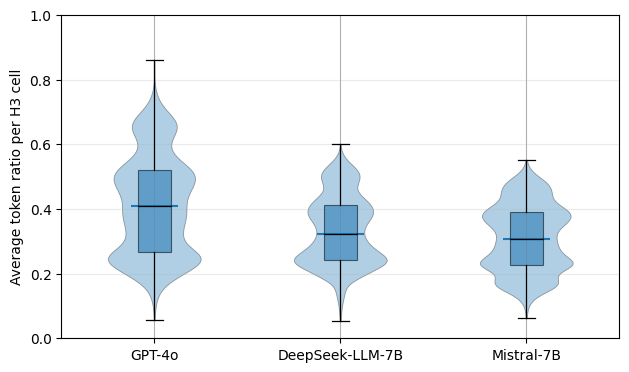

Saved: graphs/token_ratio_violin_box.png and graphs/token_ratio_violin_box.pdf


In [6]:
os.makedirs("graphs", exist_ok=True)

chat = dfq["chatgpt_avg"].dropna().clip(0, 1).to_numpy()
deep = dfq["deepseek_avg"].dropna().clip(0, 1).to_numpy()
mist = dfq["mistral_avg"].dropna().clip(0, 1).to_numpy()

data   = [chat, deep, mist]
labels = ["GPT-4o", "DeepSeek-LLM-7B", "Mistral-7B"]

fig, ax = plt.subplots(figsize=(7.2, 4.2))

vp = ax.violinplot(data, showmeans=False, showmedians=True, showextrema=False)
bp = ax.boxplot(data, widths=0.18, vert=True, patch_artist=True, showfliers=False)

for body in vp["bodies"]:
    body.set_alpha(0.35)
    body.set_edgecolor("black")
    body.set_linewidth(0.6)

for box in bp["boxes"]:
    box.set_alpha(0.55)
    box.set_edgecolor("black")
    box.set_linewidth(0.8)

for key in ["whiskers", "caps", "medians"]:
    for item in bp[key]:
        item.set_color("black")
        item.set_linewidth(0.9)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Average token ratio per H3 cell")
ax.grid(True, axis="y", alpha=0.25)

out_png = "graphs/token_ratio_violin_box.png"
out_pdf = "graphs/token_ratio_violin_box.pdf"
fig.savefig(out_png, dpi=400, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png} and {out_pdf}")

## TOKEN RATIO HISTOGRAMS PER MODE

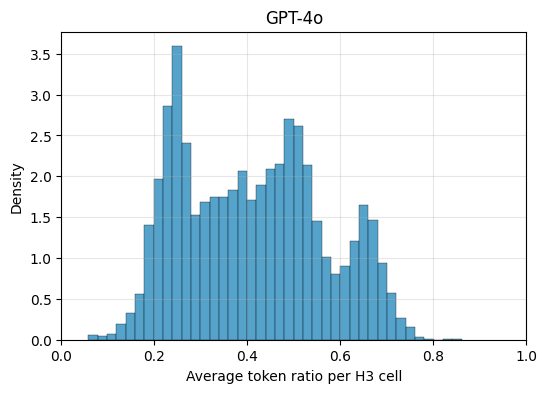

Saved: graphs/chatgpt_avg_histogram.png and graphs/chatgpt_avg_histogram.pdf


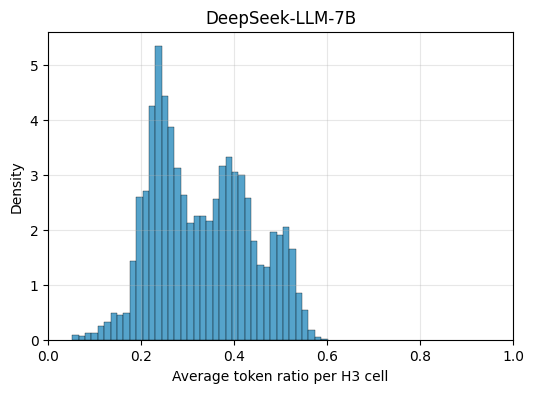

Saved: graphs/deepseek_avg_histogram.png and graphs/deepseek_avg_histogram.pdf


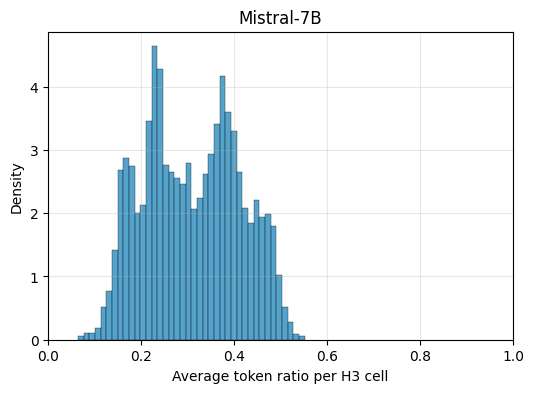

Saved: graphs/mistral_avg_histogram.png and graphs/mistral_avg_histogram.pdf


In [7]:
os.makedirs("graphs", exist_ok=True)

BINS = 40
XMIN, XMAX = 0, 1

models = [
    ("chatgpt_avg",  "GPT-4o"),
    ("deepseek_avg", "DeepSeek-LLM-7B"),
    ("mistral_avg",  "Mistral-7B"),
]

for col, label in models:
    s = dfq[col].dropna()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(s, bins=BINS, density=True,
            color="#2b8cbe", alpha=0.8,
            edgecolor="black", linewidth=0.3)
    ax.set_xlim(XMIN, XMAX)
    ax.set_xlabel("Average token ratio per H3 cell")
    ax.set_ylabel("Density")
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

    out_png = f"graphs/{col}_histogram.png"
    out_pdf = f"graphs/{col}_histogram.pdf"
    fig.savefig(out_png, dpi=400, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {out_png} and {out_pdf}")

## Cross Model Correlation

In [8]:
sub = dfq[["chatgpt_avg","deepseek_avg","mistral_avg"]].dropna()
corr = sub.corr()
corr

,chatgpt_avg,deepseek_avg,mistral_avg
chatgpt_avg,1.000000,0.963670,0.974345
deepseek_avg,0.963670,1.000000,0.973018
mistral_avg,0.974345,0.973018,1.000000


## ASSIGN CONTINENT VIA SPATIAL JOIN

In [9]:
import geopandas as gpd
from shapely.geometry import Point

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
).to_crs("EPSG:4326")

world_cont = world.dissolve(by="CONTINENT").reset_index()

gdf = gpd.GeoDataFrame(
    dfq,
    geometry=gpd.points_from_xy(dfq["centroid_lon"], dfq["centroid_lat"]),
    crs="EPSG:4326"
)

dfq = gpd.sjoin(
    gdf,
    world_cont[["CONTINENT", "geometry"]],
    how="left",
    predicate="within"
).rename(columns={"CONTINENT": "continent"}).drop(columns=["index_right"])

print(dfq["continent"].value_counts(dropna=False))

continent
Asia             1748
North America    1087
Europe           1033
Africa            970
NaN               960
South America     919
Oceania           194
Name: count, dtype: int64


## TOKEN EFFICIENCY BY CONTINENT

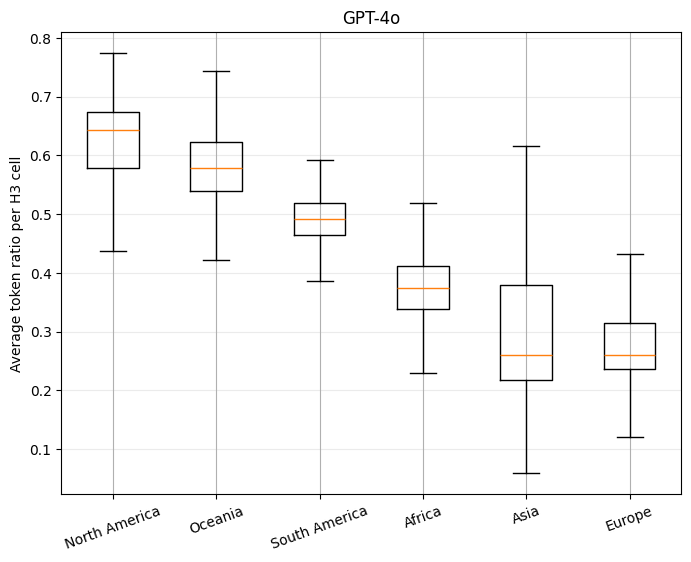

Saved: graphs/chatgpt_avg_continent_boxplot.png and graphs/chatgpt_avg_continent_boxplot.pdf


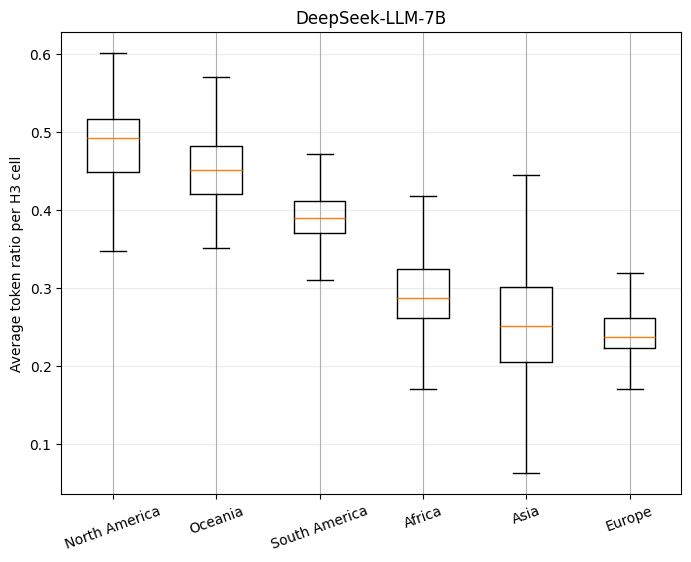

Saved: graphs/deepseek_avg_continent_boxplot.png and graphs/deepseek_avg_continent_boxplot.pdf


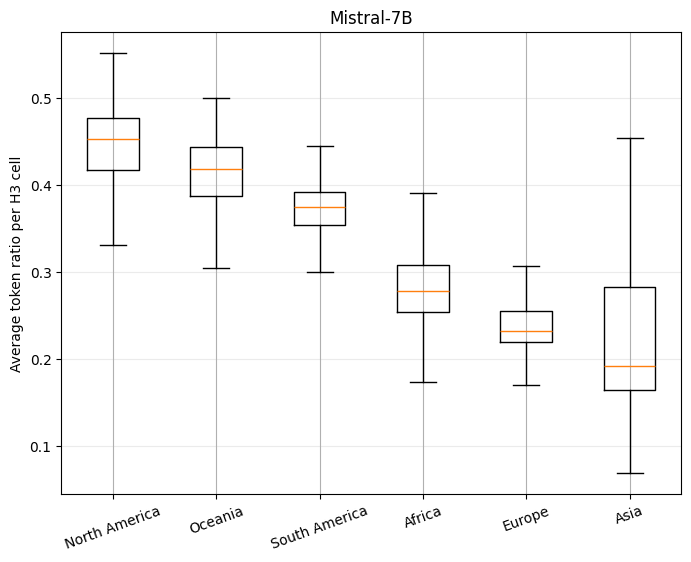

Saved: graphs/mistral_avg_continent_boxplot.png and graphs/mistral_avg_continent_boxplot.pdf
              chatgpt_avg                                    deepseek_avg                                    mistral_avg                                   
                    count   mean median    std    min    max        count   mean median    std    min    max       count   mean median    std    min    max
continent                                                                                                                                                  
Africa                970  0.379  0.375  0.063  0.189  0.674          970  0.295  0.287  0.051  0.171  0.519         970  0.284  0.279  0.047  0.163  0.480
Asia                 1748  0.297  0.260  0.105  0.059  0.796         1748  0.258  0.252  0.071  0.054  0.494        1748  0.223  0.192  0.075  0.069  0.455
Europe               1033  0.298  0.260  0.096  0.087  0.826         1033  0.258  0.237  0.064  0.104  0.503        1033  0.252

In [10]:
os.makedirs("graphs", exist_ok=True)

models = [
    ("chatgpt_avg",  "GPT-4o"),
    ("deepseek_avg", "DeepSeek-LLM-7B"),
    ("mistral_avg",  "Mistral-7B"),
]

for col, label in models:
    order = dfq.groupby("continent")[col].median().sort_values(ascending=False).index
    data  = [dfq.loc[dfq["continent"] == r, col].dropna().values for r in order]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.boxplot(data, labels=order, showfliers=False)
    ax.set_ylabel("Average token ratio per H3 cell")
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, axis="y", alpha=0.25)

    out_png = f"graphs/{col}_continent_boxplot.png"
    out_pdf = f"graphs/{col}_continent_boxplot.pdf"
    fig.savefig(out_png, dpi=400, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {out_png} and {out_pdf}")

# summary statistics by continent
continent_summary = (
    dfq.groupby("continent")[["chatgpt_avg", "deepseek_avg", "mistral_avg"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)
print(continent_summary.to_string())

## ASSIGN MACRO REGION VIA SPATIAL JOIN 

In [11]:
countries = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)[["NAME", "ISO_A3", "CONTINENT", "SUBREGION", "geometry"]].to_crs("EPSG:4326")

sub_to_macro = {
    "Northern Europe":           "Europe Northern",
    "Western Europe":            "Europe Western",
    "Eastern Europe":            "Europe Eastern",
    "Southern Europe":           "Europe Southern",
    "Eastern Asia":              "Asia East",
    "South-Eastern Asia":        "Asia Southeast",
    "Southern Asia":             "Asia South",
    "Western Asia":              "Asia West (Middle East)",
    "Central Asia":              "Asia Central",
    "Northern Africa":           "Africa North",
    "Western Africa":            "Africa West",
    "Middle Africa":             "Africa Central",
    "Eastern Africa":            "Africa East",
    "Southern Africa":           "Africa Southern",
    "Northern America":          "Americas North",
    "Caribbean":                 "Americas Caribbean",
    "Central America":           "Americas Central",
    "South America":             "Americas South",
    "Australia and New Zealand": "Oceania",
    "Melanesia":                 "Oceania",
    "Micronesia":                "Oceania",
    "Polynesia":                 "Oceania",
}

countries["macro_region"] = countries["SUBREGION"].map(sub_to_macro)

macro_polys = (
    countries.dropna(subset=["macro_region"])
             .dissolve(by="macro_region", as_index=False)
             [["macro_region", "geometry"]]
)

# buffer 25km to catch coastal H3 centroids
macro_polys_buf = (
    macro_polys
    .to_crs(3857)
    .assign(geometry=lambda d: d.buffer(25_000))
    .to_crs(4326)
)

gdf = gpd.GeoDataFrame(
    dfq,
    geometry=gpd.points_from_xy(dfq["centroid_lon"], dfq["centroid_lat"]),
    crs="EPSG:4326"
)

dfq = (
    gpd.sjoin(gdf, macro_polys_buf, how="left", predicate="within")
       .drop(columns=["index_right"])
)

print(dfq["macro_region"].value_counts(dropna=False))

macro_region
Americas South             959
Americas North             923
Europe Eastern             676
Asia East                  650
NaN                        609
Asia South                 479
Asia Southeast             366
Africa West                328
Africa East                304
Asia West (Middle East)    289
Oceania                    211
Europe Northern            210
Americas Central           198
Africa Central             183
Africa North               171
Asia Central               158
Europe Southern            121
Europe Western             114
Africa Southern             46
Americas Caribbean          37
Name: count, dtype: int64


## TOKEN EFFICIENCY BY MACRO REGION


In [12]:
os.makedirs("graphs", exist_ok=True)

N = 12
top_macro = dfq["macro_region"].value_counts().head(N).index.tolist()

models = [
    ("chatgpt_avg",  "GPT-4o"),
    ("deepseek_avg", "DeepSeek-LLM-7B"),
    ("mistral_avg",  "Mistral-7B"),
]

for col, label in models:
    use   = dfq[dfq["macro_region"].isin(top_macro)]
    order = use.groupby("macro_region")[col].median().sort_values(ascending=False).index
    data  = [use.loc[use["macro_region"] == r, col].dropna().values for r in order]

    fig, ax = plt.subplots(figsize=(10, 6))

    bp = ax.boxplot(
        data,
        labels=order,
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color="black",   linewidth=1.2),
        whiskerprops=dict(color="#555555", linewidth=0.9),
        capprops=dict(color="#555555",    linewidth=0.9),
        boxprops=dict(edgecolor="#555555", linewidth=0.9),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("#6c8ebf")
        patch.set_alpha(0.75)

    ax.set_ylabel("Average token ratio per H3 cell")
    ax.set_title(label)
    ax.set_xticklabels(order, rotation=25, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    out_png = f"graphs/{col}_macro_region_boxplot.png"
    out_pdf = f"graphs/{col}_macro_region_boxplot.pdf"
    fig.savefig(out_png, dpi=400, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_png} and {out_pdf}")

Saved: graphs/chatgpt_avg_macro_region_boxplot.png and graphs/chatgpt_avg_macro_region_boxplot.pdf
Saved: graphs/deepseek_avg_macro_region_boxplot.png and graphs/deepseek_avg_macro_region_boxplot.pdf
Saved: graphs/mistral_avg_macro_region_boxplot.png and graphs/mistral_avg_macro_region_boxplot.pdf


## SPATIAL WEIGHTS: H3 RING-1 NEIGHBORS WITH FULL CONNECTIVITY

In [14]:

import math
import networkx as nx
from libpysal.weights import W
from esda.moran import Moran

def haversine(lon1, lat1, lon2, lat2):
    """Compute great-circle distance in meters between two points."""
    R = 6_371_000.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlmb / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))

def nearest_cell_idx(lat, lon, other_lats, other_lons):
    """Return the index of the nearest cell using Euclidean prefilter then Haversine."""
    rough = np.sqrt((other_lats - lat) ** 2 + (other_lons - lon) ** 2)
    j0    = int(np.argmin(rough))
    best, bestj = float("inf"), j0
    for j in range(len(other_lats)):
        d = haversine(lon, lat, other_lons[j], other_lats[j])
        if d < best:
            best, bestj = d, j
    return bestj

# build H3 ring-1 neighbor dictionary
cells = dfq["h3_cell"].tolist()
idx   = {c: i for i, c in enumerate(cells)}
neighbors = {i: [] for i in range(len(cells))}

for i, c in enumerate(cells):
    for nh in h3.k_ring(c, 1):
        if nh == c:
            continue
        j = idx.get(nh)
        if j is not None:
            neighbors[i].append(j)

# connect isolated cells to their nearest neighbor
lats = dfq["centroid_lat"].to_numpy()
lons = dfq["centroid_lon"].to_numpy()

for i in range(len(cells)):
    if len(neighbors[i]) == 0:
        mask   = np.ones(len(cells), dtype=bool)
        mask[i] = False
        j_mask = nearest_cell_idx(lats[i], lons[i], lats[mask], lons[mask])
        full_j = np.arange(len(cells))[mask][j_mask]
        neighbors[i].append(full_j)
        neighbors[full_j].append(i)

# build initial weights and check connectivity
w_h3 = W(neighbors, id_order=list(range(len(cells))))
w_h3.transform = "r"

G = w_h3.to_networkx().to_undirected()
print(f"Initial connected components: {nx.number_connected_components(G)}")

def bridge_components_once(G, lats, lons, neighbors):
    """Bridge the two closest disconnected components with one edge."""
    comps = [list(c) for c in nx.connected_components(G)]
    if len(comps) <= 1:
        return False
    centroids = [
        (float(np.mean(lats[comp])), float(np.mean(lons[comp])))
        for comp in comps
    ]
    best_pair = (0, 1, float("inf"))
    for i in range(len(comps)):
        for j in range(i + 1, len(comps)):
            d = haversine(centroids[i][1], centroids[i][0],
                          centroids[j][1], centroids[j][0])
            if d < best_pair[2]:
                best_pair = (i, j, d)
    A, B = comps[best_pair[0]], comps[best_pair[1]]
    best = (None, None, float("inf"))
    for i in A:
        for j in B:
            d = haversine(lons[i], lats[i], lons[j], lats[j])
            if d < best[2]:
                best = (i, j, d)
    ni, nj = best[0], best[1]
    neighbors[ni].append(nj)
    neighbors[nj].append(ni)
    G.add_edge(ni, nj)
    return True

bridges = 0
while nx.number_connected_components(G) > 1 and bridges < 100_000:
    if not bridge_components_once(G, lats, lons, neighbors):
        break
    bridges += 1

print(f"Bridges added: {bridges}")
print(f"Connected components after bridging: {nx.number_connected_components(G)}")

# rebuild weights after bridging
w_h3 = W(neighbors, id_order=list(range(len(cells))))
w_h3.transform = "r"

def subW_from_neighbors(valid_idx, neighbors):
    """Build a libpysal W for a subset of nodes from the global neighbor dict."""
    idx_map  = {old_i: new_i for new_i, old_i in enumerate(valid_idx)}
    neigh_sub = {
        idx_map[old_i]: [idx_map[nj] for nj in neighbors[old_i] if nj in idx_map]
        for old_i in valid_idx
    }
    w_sub = W(neigh_sub, id_order=list(range(len(valid_idx))))
    w_sub.transform = "r"
    return w_sub

# ── GLOBAL MORAN'S I ──────────────────────────────────────────────────────────
print("\nGlobal Moran's I:")
for col, label in [("chatgpt_avg",  "GPT-4o"),
                   ("deepseek_avg", "DeepSeek-LLM-7B"),
                   ("mistral_avg",  "Mistral-7B")]:
    s         = dfq[col].astype(float)
    valid_idx = np.where(s.notna().values)[0]
    w_sub     = subW_from_neighbors(valid_idx, neighbors)
    mor       = Moran(s.iloc[valid_idx].values, w_sub, permutations=999)
    print(f"  {label}: I = {mor.I:.3f}, p = {mor.p_sim:.4f}")

/tmp/ipykernel_560943/2362101507.py:53: UserWarning: The weights matrix is not fully connected: 
 There are 111 disconnected components.
  w_h3 = W(neighbors, id_order=list(range(len(cells))))


Initial connected components: 111
Bridges added: 110
Connected components after bridging: 1

Global Moran's I:
  GPT-4o: I = 0.920, p = 0.0010
  DeepSeek-LLM-7B: I = 0.917, p = 0.0010
  Mistral-7B: I = 0.924, p = 0.0010


# LOCAL MORAN'S I (LISA)

In [15]:

def lisa_clusters(values, w, alpha=0.05):
    """
    Compute LISA cluster labels for a set of values.
    Returns cluster array (0=not significant, 1=HH, 2=LH, 3=LL, 4=HL)
    and p-values from permutation test.
    """
    y  = (values - values.mean()) / values.std()
    ml = Moran_Local(y, w, permutations=999)

    cl  = np.zeros_like(ml.q)
    sig = ml.p_sim < alpha
    cl[sig & (ml.q == 1)] = 1  # High-High
    cl[sig & (ml.q == 2)] = 2  # Low-High
    cl[sig & (ml.q == 3)] = 3  # Low-Low
    cl[sig & (ml.q == 4)] = 4  # High-Low

    return cl, ml.p_sim

for col, label in [("chatgpt_avg",  "GPT-4o"),
                   ("deepseek_avg", "DeepSeek-LLM-7B"),
                   ("mistral_avg",  "Mistral-7B")]:
    s         = dfq[col].astype(float)
    valid_idx = np.where(s.notna().values)[0]
    w_sub     = subW_from_neighbors(valid_idx, neighbors)
    cl, p     = lisa_clusters(s.iloc[valid_idx].values, w_sub)

    out_c = np.full(len(dfq), np.nan)
    out_p = np.full(len(dfq), np.nan)
    out_c[valid_idx] = cl
    out_p[valid_idx] = p

    dfq[f"{col}_cluster"] = out_c
    dfq[f"{col}_p"]       = out_p

    print(f"{label} — cluster value counts:")
    print(dfq[f"{col}_cluster"].value_counts().sort_index())
    print()

GPT-4o — cluster value counts:
chatgpt_avg_cluster
0.0    3790
1.0    1626
2.0       5
3.0    2211
4.0       8
Name: count, dtype: int64

DeepSeek-LLM-7B — cluster value counts:
deepseek_avg_cluster
0.0    3706
1.0    1748
2.0       7
3.0    2174
4.0       5
Name: count, dtype: int64

Mistral-7B — cluster value counts:
mistral_avg_cluster
0.0    3682
1.0    1829
2.0       9
3.0    2113
4.0       7
Name: count, dtype: int64



## TOP AND BOTTOM 10 COUNTRIES BY TOKEN EFFICIENCY

In [20]:

country_means = (
    dfq.drop_duplicates(subset="h3_cell")
       .groupby("country")[["chatgpt_avg", "deepseek_avg", "mistral_avg"]]
       .mean()
       .dropna()
       .reset_index()
)

models = [
    ("chatgpt_avg",  "GPT-4o"),
    ("deepseek_avg", "DeepSeek-LLM-7B"),
    ("mistral_avg",  "Mistral-7B"),
]

for col, label in models:
    top10 = country_means.nlargest(10,  col)[["country", col]].reset_index(drop=True)
    bot10 = country_means.nsmallest(10, col)[["country", col]].reset_index(drop=True)

    print(f"\n{label} — Top 10 (highest token ratio):")
    print(top10.to_string(index=False))

    print(f"\n{label} — Bottom 10 (lowest token ratio):")
    print(bot10.to_string(index=False))


GPT-4o — Top 10 (highest token ratio):
                 country  chatgpt_avg
            Falkland Is.     0.718000
                 Bahamas     0.705500
United States of America     0.662696
                 Jamaica     0.656000
     Trinidad and Tobago     0.636000
                  Belize     0.616000
                  Canada     0.603154
                  Guyana     0.603000
               Australia     0.595319
               Nicaragua     0.564818

GPT-4o — Bottom 10 (lowest token ratio):
    country  chatgpt_avg
     Greece     0.171692
      Japan     0.173714
    Myanmar     0.180100
     Taiwan     0.185800
    Georgia     0.187750
South Korea     0.203385
      China     0.214039
     Israel     0.222400
  Lithuania     0.226833
    Belarus     0.227000

DeepSeek-LLM-7B — Top 10 (highest token ratio):
                 country  deepseek_avg
            Falkland Is.      0.547500
                 Bahamas      0.541000
United States of America      0.508003
     Trinidad and To

## TOP AND BOTTOM 10 H3 CELLS BY TOKEN EFFICIENCY

In [23]:
from collections import Counter

TOPK_NAMES_PREVIEW = 10

def extract_names_list(entries):
    """Extract place name strings from a list of entry dicts or strings."""
    names = []
    for e in entries or []:
        if isinstance(e, str):
            names.append(e)
        elif isinstance(e, dict):
            for k in ("name", "Name", "gazetteer_name", "place", "label"):
                if k in e and isinstance(e[k], str):
                    names.append(e[k])
                    break
    return names

def names_preview(entries, k=TOPK_NAMES_PREVIEW):
    """Return a formatted string of the k most frequent names in a cell."""
    names = extract_names_list(entries)
    if not names:
        return ""
    top = Counter(names).most_common(k)
    return ", ".join(f"{n} ({c})" for n, c in top)

# build cell-level dataframe from raw JSON
rows = []
for cell, info in raw.items():
    entries = info.get("entries", []) if isinstance(info, dict) else []
    n_names = len(entries) if isinstance(entries, list) else 0
    if n_names < MIN_NAMES:
        continue

    chat = info.get("chatgpt_avg_token_ratio",  float("nan"))
    deep = info.get("deepseek_avg_token_ratio", float("nan"))
    mist = info.get("mistral_avg_token_ratio",  float("nan"))

    numeric_vals = [v for v in (chat, deep, mist)
                    if isinstance(v, (int, float)) and not math.isnan(v)]
    if not numeric_vals:
        continue

    lat, lon = h3.h3_to_geo(cell)
    rows.append({
        "cell":          cell,
        "lat":           float(lat),
        "lon":           float(lon),
        "n_names":       n_names,
        "chatgpt_avg":   chat,
        "deepseek_avg":  deep,
        "mistral_avg":   mist,
        "names_preview": names_preview(entries),
    })

df_cells = pd.DataFrame(rows)
if df_cells.empty:
    raise ValueError("No cells remaining after filtering. Check MIN_NAMES or JSON structure.")

print(f"Cells included: {len(df_cells):,}")

# ranking helper
def top_bottom(df, col, n=10):
    """Return top n and bottom n rows by column value."""
    sub  = df[pd.to_numeric(df[col], errors="coerce").notna()].copy()
    cols = ["cell", "lat", "lon", "n_names", col, "names_preview"]
    top  = sub.nlargest(n,  col)[cols].reset_index(drop=True)
    bot  = sub.nsmallest(n, col)[cols].reset_index(drop=True)
    return top, bot

models = [
    ("chatgpt_avg",  "GPT-4o"),
    ("deepseek_avg", "DeepSeek-LLM-7B"),
    ("mistral_avg",  "Mistral-7B"),
]

for col, label in models:
    top10, bot10 = top_bottom(df_cells, col)

    print(f"\n{label} — Top 10 cells (highest token ratio):")
    print(top10.to_string(index=False))

    print(f"\n{label} — Bottom 10 cells (lowest token ratio):")
    print(bot10.to_string(index=False))

Cells included: 6,911

GPT-4o — Top 10 cells (highest token ratio):
           cell        lat         lon  n_names  chatgpt_avg                                                                                                                                                                                                                                        names_preview
8326ddfffffffff  33.673865  -99.103040      148        0.861                                                                                                           Young Wind (86), Throckmorton (2), Brown Lake Dam (2), Irby (1), Mattson (1), Sunset (1), Munday (1), Rhineland (1), Goree (1), Hefner (1)
83c203fffffffff -38.324479  -57.651838      109        0.833                          Mar del Sur (4), Centinela del Mar (1), Estancia Las Cortaderas (1), Estancia Lucila (1), San José de Otamendi (1), La Eufemia (1), Boulevard Atlántico (1), Estancia La Toto (1), Paraje Santa Irene (1), La Ballenera (1)
830183ffffffff

## COUNTRY RANKINGS BY TOKEN EFFICIENCY

In [24]:
MIN_CELLS = 5
TOP_N     = 10

required_cols = {"country", "h3_cell", "chatgpt_avg", "deepseek_avg", "mistral_avg"}
missing = required_cols - set(dfq.columns)
assert not missing, f"dfq is missing columns: {missing}"

country_stats = (
    dfq.drop_duplicates(subset="h3_cell")
       .groupby("country")
       .agg(
           chatgpt_mean  = ("chatgpt_avg",  "mean"),
           deepseek_mean = ("deepseek_avg", "mean"),
           mistral_mean  = ("mistral_avg",  "mean"),
           n_cells       = ("h3_cell",      "nunique"),
       )
       .reset_index()
)

country_stats = country_stats[country_stats["n_cells"] >= MIN_CELLS].copy()

if country_stats.empty:
    raise ValueError("No countries remaining after filtering by MIN_CELLS.")

models = [
    ("chatgpt_mean",  "GPT-4o"),
    ("deepseek_mean", "DeepSeek-LLM-7B"),
    ("mistral_mean",  "Mistral-7B"),
]

for col, label in models:
    sub  = country_stats[country_stats[col].notna()]
    top  = sub.nlargest(TOP_N,  col)[["country", col, "n_cells"]].reset_index(drop=True)
    bot  = sub.nsmallest(TOP_N, col)[["country", col, "n_cells"]].reset_index(drop=True)

    print(f"\n{label} — Top {TOP_N} countries (highest token ratio):")
    print(top.to_string(index=False))

    print(f"\n{label} — Bottom {TOP_N} countries (lowest token ratio):")
    print(bot.to_string(index=False))


GPT-4o — Top 10 countries (highest token ratio):
                 country  chatgpt_mean  n_cells
United States of America      0.662696      651
                  Canada      0.603154      260
               Australia      0.595319      185
               Nicaragua      0.564818       11
              Costa Rica      0.543429        7
               Guatemala      0.536571        7
                  Panama      0.529143        7
               Venezuela      0.525286       49
                  Mexico      0.524800      145
          Dominican Rep.      0.522778        9

GPT-4o — Bottom 10 countries (lowest token ratio):
    country  chatgpt_mean  n_cells
     Greece      0.171692       13
      Japan      0.173714       49
    Myanmar      0.180100       50
     Taiwan      0.185800        5
South Korea      0.203385       13
      China      0.214039      512
     Israel      0.222400        5
  Lithuania      0.226833        6
    Belarus      0.227000       19
North Korea      0.2

# RANK STABILITY ACROSS MODELS BY COUNTRY

In [25]:
MIN_CELLS = 5

required = {"country", "h3_cell", "chatgpt_avg", "deepseek_avg", "mistral_avg"}
missing  = required - set(dfq.columns)
assert not missing, f"dfq is missing columns: {missing}"

country_stats = (
    dfq.drop_duplicates(subset="h3_cell")
       .dropna(subset=["country"])
       .groupby("country")
       .agg(
           n_cells       = ("h3_cell",      "count"),
           chatgpt_mean  = ("chatgpt_avg",  "mean"),
           deepseek_mean = ("deepseek_avg", "mean"),
           mistral_mean  = ("mistral_avg",  "mean"),
           chatgpt_std   = ("chatgpt_avg",  "std"),
           deepseek_std  = ("deepseek_avg", "std"),
           mistral_std   = ("mistral_avg",  "std"),
       )
       .reset_index()
)

country_stats = country_stats[country_stats["n_cells"] >= MIN_CELLS].copy()

# Spearman rank correlations
r_cd = spearman_from_series(country_stats["chatgpt_mean"], country_stats["deepseek_mean"])
r_cm = spearman_from_series(country_stats["chatgpt_mean"], country_stats["mistral_mean"])
r_dm = spearman_from_series(country_stats["deepseek_mean"], country_stats["mistral_mean"])

print("Spearman rank correlation based on country means:")
print(f"  GPT-4o vs DeepSeek-LLM-7B:        {r_cd:.3f}")
print(f"  GPT-4o vs Mistral-7B:              {r_cm:.3f}")
print(f"  DeepSeek-LLM-7B vs Mistral-7B:     {r_dm:.3f}")

# top and bottom 10 per model
models = [
    ("chatgpt_mean",  "GPT-4o"),
    ("deepseek_mean", "DeepSeek-LLM-7B"),
    ("mistral_mean",  "Mistral-7B"),
]

for col, label in models:
    top = country_stats.sort_values(col, ascending=False).head(10)[["country", "n_cells", col]]
    bot = country_stats.sort_values(col, ascending=True).head(10)[["country", "n_cells", col]]

    print(f"\n{label} — Top 10 countries:")
    print(top.to_string(index=False))

    print(f"\n{label} — Bottom 10 countries:")
    print(bot.to_string(index=False))

country_stats.to_csv("exports/country_level_token_efficiency_stats.csv", index=False)
print("\nSaved: exports/country_level_token_efficiency_stats.csv")

Spearman rank correlation based on country means:
  GPT-4o vs DeepSeek-LLM-7B:        0.975
  GPT-4o vs Mistral-7B:              0.975
  DeepSeek-LLM-7B vs Mistral-7B:     0.986

GPT-4o — Top 10 countries:
                 country  n_cells  chatgpt_mean
United States of America      651      0.662696
                  Canada      260      0.603154
               Australia      185      0.595319
               Nicaragua       11      0.564818
              Costa Rica        7      0.543429
               Guatemala        7      0.536571
                  Panama        7      0.529143
               Venezuela       49      0.525286
                  Mexico      145      0.524800
          Dominican Rep.        9      0.522778

GPT-4o — Bottom 10 countries:
    country  n_cells  chatgpt_mean
     Greece       13      0.171692
      Japan       49      0.173714
    Myanmar       50      0.180100
     Taiwan        5      0.185800
South Korea       13      0.203385
      China      512     